# Workshop: Robust Digital Watermarking (DWT-DCT vs. RivaGAN)

This notebook walks through **embedding**, **extracting**, and **robustness testing** of digital watermarks using:
- **DWT-DCT** — classical, signal-processing based (no training needed)
- **RivaGAN** — learning-based, uses a pre-trained encoder/decoder network

We will also measure image quality (PSNR / SSIM), and visualize with images, difference maps, tables, and charts.

## 0. Setup
Run the following cell to install and import all dependencies.
Works on **Google Colab**, **Jupyter Lab**, or local Jupyter. Install and import libraries for image processing (OpenCV), visualization (Matplotlib),
numerical computation (NumPy), data handling (Pandas), and watermark encoding/decoding.

In [1]:
# Install packages (uncomment if needed)
!pip -q install invisible-watermark opencv-python-headless matplotlib numpy pandas scikit-image onnxruntime

import os, io, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imwatermark import WatermarkEncoder, WatermarkDecoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 116.8 MB/s eta 0:00:00


PSNR measures pixel-level differences between images; higher values mean less distortion.
SSIM measures perceptual/structural similarity; values closer to 1 indicate higher visual similarity.

In [16]:
# We use PSNR/SSIM to measure watermark invisibility
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity  as compute_ssim

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 100})
print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


## 1. Load an Input Image

Set `IMAGE_PATH` below. If the file doesn't exist, we **auto-download** a sample image so the notebook never fails on first run.

The image is 1920×1080.

Image shape: (1080, 1920, 3)


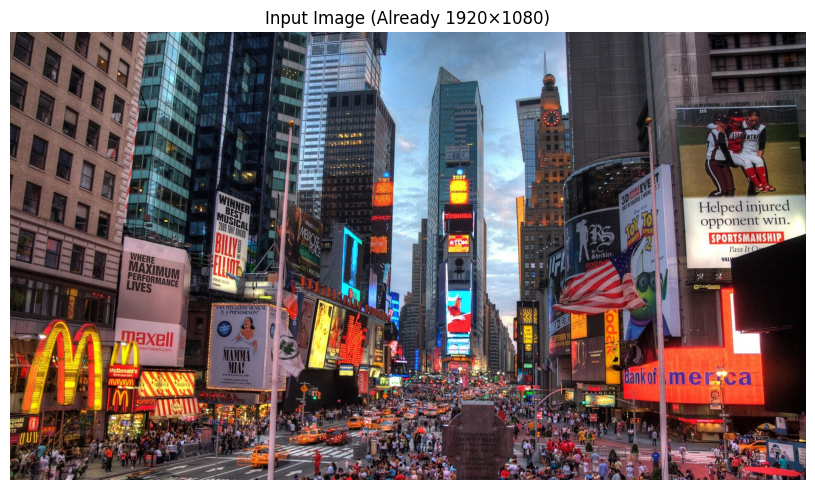

In [17]:
IMAGE_PATH = "nyc.jpg"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}\n"
        "Please first upload the image to the directory where this notebook is located."
    )

img_bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read: {IMAGE_PATH}")

print(f"Image shape: {img_bgr.shape}")
img_1080p = img_bgr

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input Image (1920×1080)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Helper Functions

We define reusable utilities:
- **`show_comparison()`** — side-by-side: Original vs Watermarked vs Amplified Difference
- **`quality_table()`** — compute PSNR & SSIM for watermarked images


In [18]:
def show_comparison(original, watermarked, method_name, amp_factor=10):
    """Show Original | Watermarked | Amplified Difference (×amp_factor)."""
    diff = cv2.absdiff(original, watermarked)
    diff_amp = np.clip(diff.astype(np.float32) * amp_factor, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, img, title in zip(axes, [original, watermarked, diff_amp],
            ["Original", f"{method_name} Watermarked", f"Difference (×{amp_factor})"]):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.suptitle(f"Watermark Embedding — {method_name}", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

def quality_metrics(original, watermarked):
    """Return (PSNR, SSIM) between two BGR images."""
    orig_rgb = cv2.cvtColor(original,    cv2.COLOR_BGR2RGB)
    wm_rgb   = cv2.cvtColor(watermarked, cv2.COLOR_BGR2RGB)
    psnr = compute_psnr(orig_rgb, wm_rgb)
    ssim = compute_ssim(orig_rgb, wm_rgb, channel_axis=2)
    return round(psnr, 2), round(ssim, 4)

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 3. Watermark Method A — DWT-DCT (Classical)

DWT-DCT embeds the watermark in the **frequency domain** using Discrete Wavelet Transform + Discrete Cosine Transform. No neural network is needed.

We embed `test` (4 ASCII chars = 32 bits) and immediately verify decoding.


Embedded         : test
Raw decoded bytes: b'test'
Decoded text     : test
PSNR     : 38.73 dB
SSIM     : 0.981


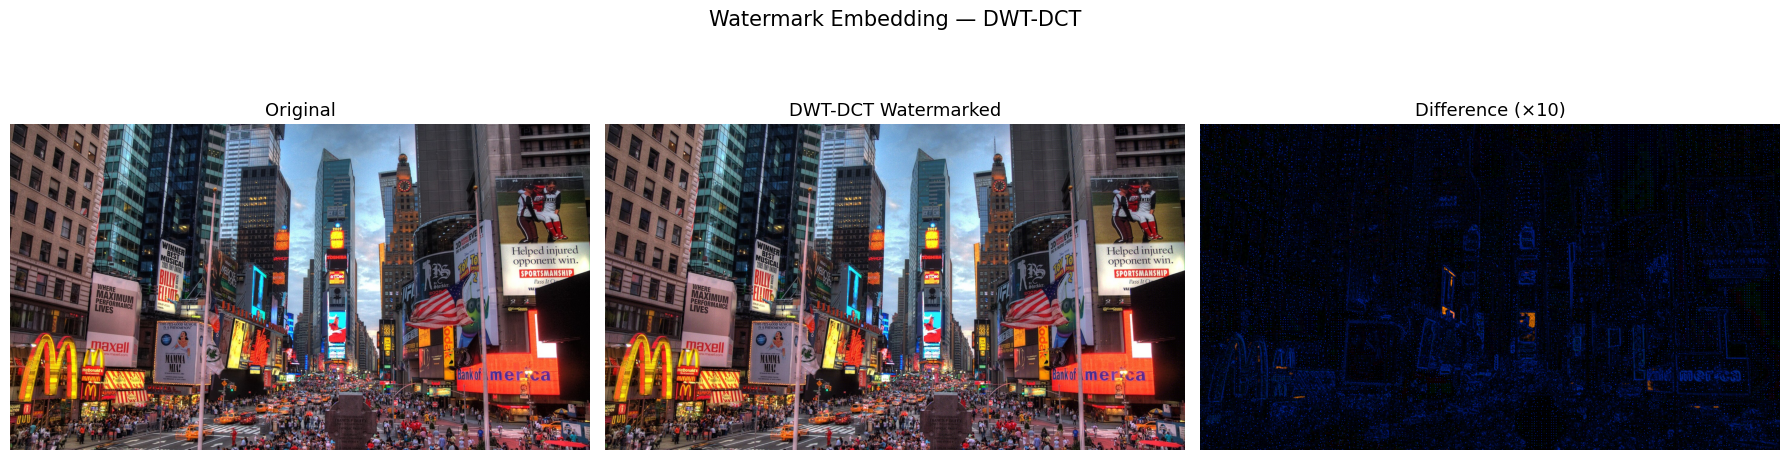

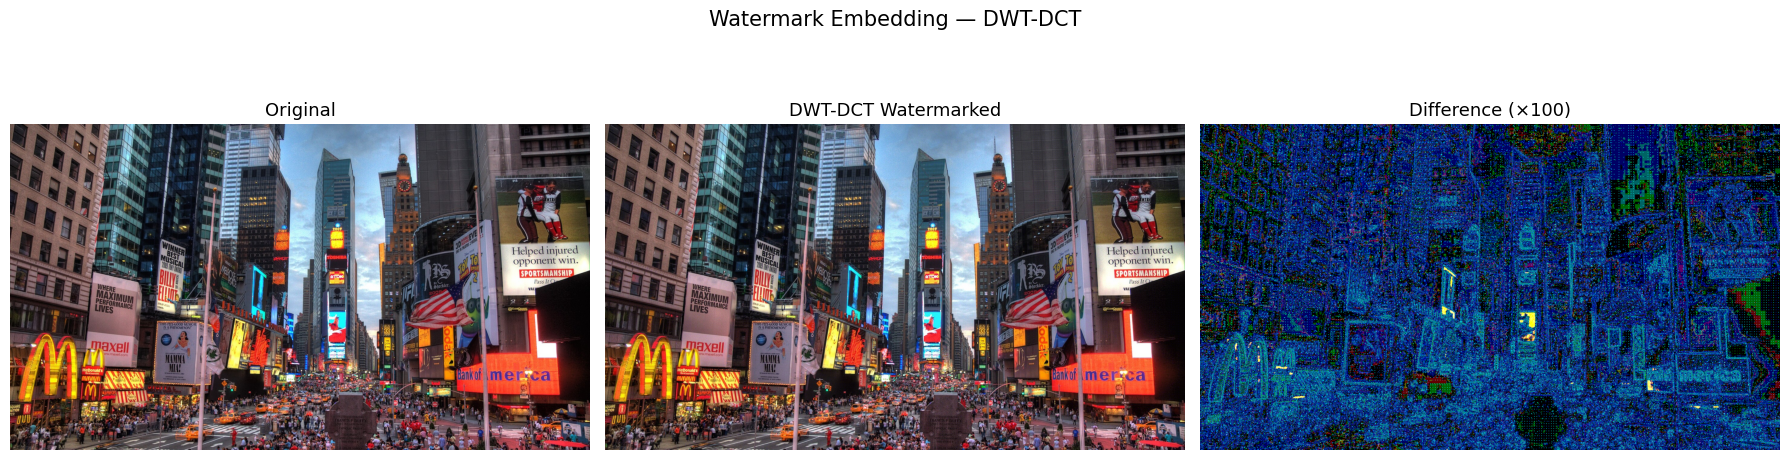

In [19]:

# # --- Visual comparison with difference map ---

wm_text_dwt = "test"

enc_dwt = WatermarkEncoder()
enc_dwt.set_watermark("bytes", wm_text_dwt.encode("utf-8"))
wm_dwt_bgr = enc_dwt.encode(img_1080p, "dwtDct").astype(np.uint8)

dec_dwt = WatermarkDecoder("bytes", len(wm_text_dwt.encode("utf-8")) * 8)
decoded_dwt = dec_dwt.decode(wm_dwt_bgr, "dwtDct")

print("Embedded         :", wm_text_dwt)
print("Raw decoded bytes:", decoded_dwt)
print("Decoded text     :", decoded_dwt.decode("utf-8", errors="replace"))

# quality metrics
psnr_dwt, ssim_dwt = quality_metrics(img_1080p, wm_dwt_bgr)
print(f"PSNR     : {psnr_dwt} dB")
print(f"SSIM     : {ssim_dwt}")

show_comparison(img_1080p, wm_dwt_bgr, "DWT-DCT")
show_comparison(img_1080p, wm_dwt_bgr, "DWT-DCT", amp_factor=100)





## 4. Watermark Method B — RivaGAN (Deep Learning)

RivaGAN uses a **pre-trained encoder-decoder network**. The provided model supports a **32-bit** payload (= 4 ASCII characters).

We embed `test` and verify, then compare the difference map with DWT-DCT.

Embedded : test
Decoded  : test
PSNR     : 40.48 dB
SSIM     : 0.9834


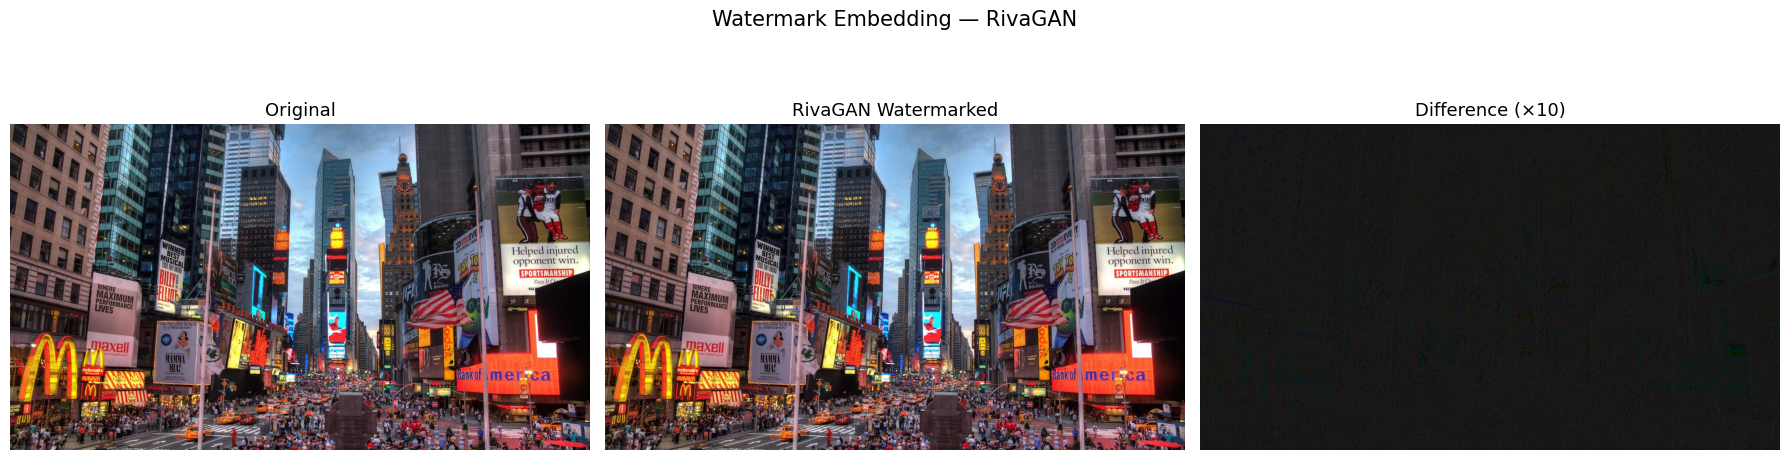

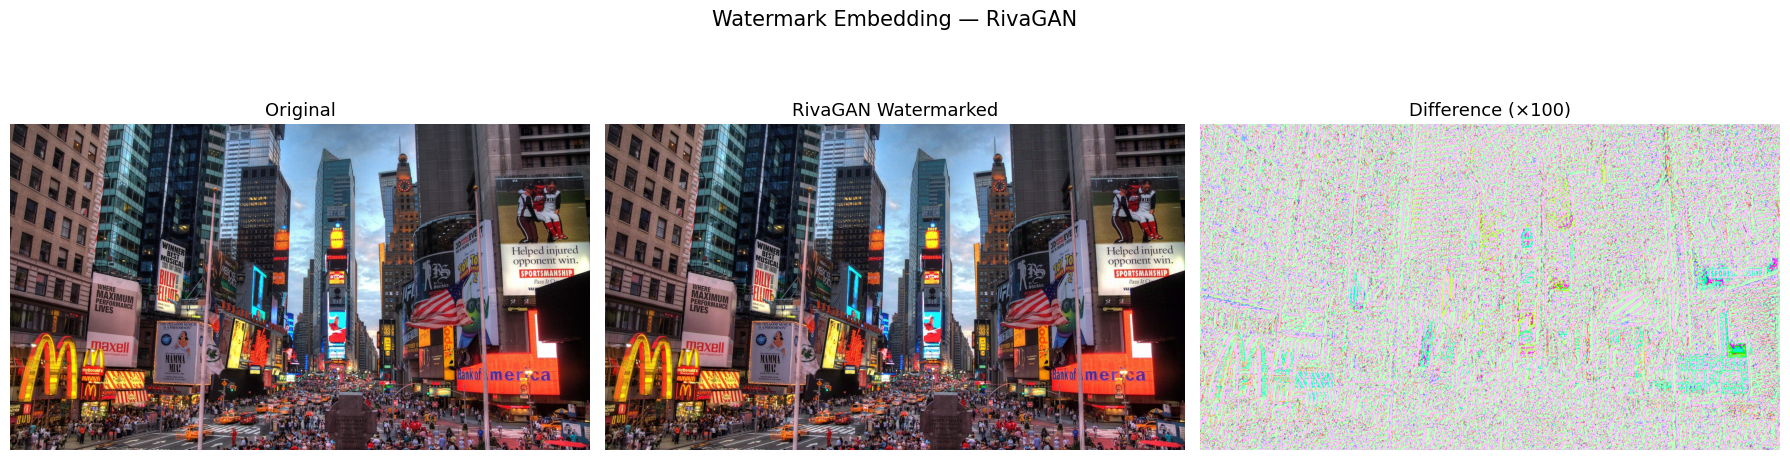

In [20]:
# Load pre-trained RivaGAN model
WatermarkEncoder.loadModel()
WatermarkDecoder.loadModel()

wm_text_riva = "test"  # 4 chars = 32 bits (model limit)

# --- Encode ---
enc_riva = WatermarkEncoder()
enc_riva.set_watermark("bytes", wm_text_riva.encode("utf-8"))
wm_riva_bgr = enc_riva.encode(img_1080p, "rivaGan").astype(np.uint8)

# --- Decode & verify ---
dec_riva = WatermarkDecoder("bytes", 32)
decoded_riva = dec_riva.decode(wm_riva_bgr, "rivaGan")
print(f"Embedded : {wm_text_riva}")
print(f"Decoded  : {decoded_riva.decode('utf-8', errors='ignore')}")

# --- Quality metrics ---
psnr_riva, ssim_riva = quality_metrics(img_1080p, wm_riva_bgr)
print(f"PSNR     : {psnr_riva} dB")
print(f"SSIM     : {ssim_riva}")

# --- Visual comparison with difference map ---
show_comparison(img_1080p, wm_riva_bgr, "RivaGAN")
show_comparison(img_1080p, wm_riva_bgr, "RivaGAN", amp_factor=100)

### Quality Comparison Table

Higher PSNR and SSIM indicate better visual fidelity. In general, PSNR above 35 dB and SSIM close to 1 suggest that watermark distortions are difficult to perceive.

In [21]:
quality_df = pd.DataFrame([
    {"Method": "DWT-DCT",  "Payload": wm_text_dwt,  "Bits": len(wm_text_dwt)*8, "PSNR (dB)": psnr_dwt, "SSIM": ssim_dwt},
    {"Method": "RivaGAN",  "Payload": wm_text_riva, "Bits": len(wm_text_riva)*8, "PSNR (dB)": psnr_riva, "SSIM": ssim_riva},
])
quality_df.style.format({"PSNR (dB)": "{:.2f}", "SSIM": "{:.4f}"}).set_caption("Watermark Invisibility")

,Method,Payload,Bits,PSNR (dB),SSIM
0,DWT-DCT,test,32,38.73,0.9810
1,RivaGAN,test,32,40.48,0.9834
